# 12. Anomaly Detection for Logs, Events, and Sequences

Logs are different from the tabular measurements we have used so far. They are semi-structured traces of behavior: users attempt login, services call dependencies, jobs retry, permissions change, orders settle, and systems emit warnings. A single line may not look unusual, but a sequence of lines can reveal a failure, attack, abuse pattern, or process deviation.

This notebook develops log and event-sequence anomaly detection as a decision-science workflow. We will convert raw event streams into templates, estimate normal event and transition probabilities, score abnormal sessions, detect bursts in event counts, and translate the outputs into operational review states.


## Learning Objectives

By the end of this notebook, you should be able to:

- Represent logs as event templates, sessions, count vectors, and ordered sequences.
- Distinguish point anomalies, transition anomalies, collective sequence anomalies, and event bursts.
- Estimate template-frequency and transition-likelihood scores from normal reference data.
- Use n-gram count representations to detect sequence deviations without a deep model.
- Combine session-level sequence scores with aggregate burst context for alert triage.
- Explain why log anomaly detection can fail when parsing, instrumentation, or user behavior changes.


## 1. Why Logs Need Their Own Treatment

A sensor reading is usually already numeric. A log line is not. A production log stream contains timestamps, components, request identifiers, user or account identifiers, severity levels, and message text. The first modeling decision is therefore representation.

A common operational workflow is:

1. **Parse raw logs into templates.** Replace volatile values such as user IDs, amounts, IP addresses, and request IDs with variables.
2. **Assign event IDs.** Treat each template as a discrete event type.
3. **Group events into units.** A unit might be a user session, request trace, job execution, account, device, host, or time window.
4. **Score abnormality.** Score rare templates, unexpected transitions, abnormal counts, unusual subsequences, or strange timing.
5. **Route decisions.** Decide whether the pattern requires incident response, fraud review, reliability investigation, suppression, or continued monitoring.

This is the same statistical decision problem as before, but the object being scored is now a sequence rather than a row.


## 2. Mathematical Setup

Let a parsed event stream be

$$
(t_1, s_1, e_1), (t_2, s_2, e_2), \ldots, (t_N, s_N, e_N),
$$

where $t_i$ is time, $s_i$ is a session or entity identifier, and $e_i$ is an event template from vocabulary $V$.

For session $s$, write the ordered event sequence as

$$
x_s = (e_{s,1}, e_{s,2}, \ldots, e_{s,L_s}).
$$

A simple template-rarity model estimates

$$
\hat p(e) = \frac{n_e + \alpha}{N + \alpha |V|},
$$

where $n_e$ is the number of times template $e$ appears in reference data and $\alpha$ is a smoothing constant. A rare-template score is

$$
R(e) = -\log \hat p(e).
$$

A first-order transition model estimates

$$
\hat p(j \mid i) = \frac{n_{ij} + \alpha}{n_i + \alpha |V|},
$$

where $n_{ij}$ counts transitions from event $i$ to event $j$. The session-level transition surprise is

$$
A_s = \frac{1}{L_s - 1}\sum_{k=2}^{L_s} -\log \hat p(e_{s,k} \mid e_{s,k-1}).
$$

This is a transparent version of the idea used by many sequence models: learn what normally follows what, then flag observations that are unlikely under the learned normal process.


## 3. Types of Log and Sequence Anomalies

| Anomaly type | What changes | Example | Useful representation |
|---|---|---|---|
| Rare template | A new or infrequent event appears | `API_TOKEN_CREATED` appears in customer sessions | Template frequency |
| Rare transition | Individually common events occur in a strange order | `LOGIN_FAIL -> BULK_EXPORT` | Markov transition probabilities |
| Collective sequence anomaly | The whole ordered path is unusual | Repeated payment timeouts before abandonment | Sequence likelihood or n-grams |
| Burst anomaly | Event volume spikes | Thousands of login failures in one hour | Time-window event counts |
| Contextual anomaly | Normal event appears in abnormal context | Admin export outside maintenance window | Event plus entity, role, time, or segment |

The decision problem is deciding whether strange logs indicate business-as-usual changes, instrumentation drift, abuse, reliability degradation, or a true incident.


## 4. Practical Modeling Choices

The table below summarizes the modeling choices we will implement.

| Layer | Question | Model used here | Why it is useful |
|---|---|---|---|
| Template rarity | Which event types are unusual? | Smoothed event probabilities | Easy to explain and debug |
| Transition rarity | Which event pairs are surprising? | Smoothed first-order Markov model | Captures order as well as counts |
| Session anomaly | Which sessions have unusual event paths? | Transition negative log-likelihood | Converts variable-length sessions into scores |
| N-gram representation | Which local subsequences look abnormal? | CountVectorizer with 1-, 2-, and 3-grams plus Isolation Forest | Captures repeated motifs without a neural sequence model |
| Burst context | Are many related events spiking together? | Hourly count residuals | Separates one-off strange sessions from system-wide incidents |

Deep models such as LSTM-based DeepLog and transformer-based LogBERT extend this logic by learning richer conditional distributions over event tokens. In this notebook, we keep the models transparent so the diagnostics and decision rules are visible.


In [1]:
# Section focus: 4. Practical Modeling Choices.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

import sys
import warnings
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import average_precision_score, precision_recall_curve, roc_auc_score
from sklearn.preprocessing import StandardScaler

repo_root = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / 'notebooks' / '_shared' / 'display.py').exists())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from notebooks._shared.display import smart_display

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 130
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['legend.fontsize'] = 8
plt.rcParams['legend.title_fontsize'] = 8
pd.set_option('display.max_columns', 140)

RANDOM_SEED = 51212
rng = np.random.default_rng(RANDOM_SEED)

PALETTE = {
    'baseline': '#64748b',
    'reference': '#2563eb',
    'monitor': '#0f766e',
    'sequence': '#7c3aed',
    'transition': '#f97316',
    'burst': '#dc2626',
    'threshold': '#111827',
    'normal': '#94a3b8',
    'incident_one': '#f59e0b',
    'incident_two': '#ef4444',
    'incident_three': '#8b5cf6',
}

INCIDENT_WINDOWS = {
    'credential_stuffing': (pd.Timestamp('2026-05-17'), pd.Timestamp('2026-05-20'), PALETTE['incident_one'], 'Credential-stuffing wave'),
    'payment_timeout_loop': (pd.Timestamp('2026-05-28'), pd.Timestamp('2026-05-31'), PALETTE['incident_two'], 'Payment timeout loop'),
    'privileged_export': (pd.Timestamp('2026-06-07'), pd.Timestamp('2026-06-09'), PALETTE['incident_three'], 'Privileged export event'),
}


def shade_incidents(ax):
    """Carry out the shade incidents step used in the 12. Anomaly Detection for Logs, Events, and Sequences workflow.
    
    Parameters
    ----------
    ax : object
        Matplotlib axis on which the plot is drawn.
    
    Returns
    -------
    object
        None. The function updates a plot, display object, or notebook state as its side effect.
    """
    for _, (start, end, color, _) in INCIDENT_WINDOWS.items():
        ax.axvspan(start, end, color=color, alpha=0.08, zorder=0)


def incident_legend_handles():
    """Carry out the incident legend handles step used in the 12. Anomaly Detection for Logs, Events, and Sequences workflow.
    
    Parameters
    ----------
    None
        This helper uses values defined in the surrounding notebook cell.
    
    Returns
    -------
    object
        Intermediate result produced by the incident legend handles calculation and reused by later cells.
    """
    return [Patch(facecolor=color, alpha=0.18, edgecolor='none', label=label) for _, (_, _, color, label) in INCIDENT_WINDOWS.items()]


def add_incident_legend(ax, loc='upper left'):
    """Carry out the add incident legend step used in the 12. Anomaly Detection for Logs, Events, and Sequences workflow.
    
    Parameters
    ----------
    ax : object
        Matplotlib axis on which the plot is drawn.
    loc : object
        The loc setting that controls the add incident legend calculation in this notebook.
    
    Returns
    -------
    object
        None. The function updates a plot, display object, or notebook state as its side effect.
    """
    handles, labels = ax.get_legend_handles_labels()
    extra = incident_legend_handles()
    ax.legend(handles + extra, labels + [h.get_label() for h in extra], loc=loc)


def robust_zscore(values, center=None, scale=None, min_scale=0.25):
    """Carry out the robust zscore step used in the 12. Anomaly Detection for Logs, Events, and Sequences workflow.
    
    Parameters
    ----------
    values : object
        The values setting that controls the robust zscore calculation in this notebook.
    center : object
        The center setting that controls the robust zscore calculation in this notebook.
    scale : object
        The scale setting that controls the robust zscore calculation in this notebook.
    min_scale : object
        The min scale setting that controls the robust zscore calculation in this notebook.
    
    Returns
    -------
    object
        Tuple of outputs from this workflow, usually data, fitted objects, or diagnostics used by later cells.
    """
    values = np.asarray(values, dtype=float)
    if center is None:
        center = np.nanmedian(values)
    if scale is None:
        scale = 1.4826 * np.nanmedian(np.abs(values - center))
    scale = max(float(scale), min_scale, 1e-6)
    return (values - center) / scale, center, scale


## 5. Synthetic Case: Payment Platform Event Logs

We will simulate a payment platform that records user and service events. The platform has mostly normal customer purchase sessions, refund-support sessions, and merchant payout sessions. Three monitored incidents occur later:

- A credential-stuffing wave creates repeated login failures and account locks.
- A payment-service issue creates timeout and retry loops.
- A privileged-export event creates rare administrative sequences.

In real logs, we often do not have clean anomaly labels. We include synthetic labels only so that we can evaluate detectors and explain what each method is recovering.


In [2]:
# Section focus: 5. Synthetic Case: Payment Platform Event Logs.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

EVENT_CATALOG = {
    'SESSION_START': ('gateway', 'info'),
    'LOGIN_ATTEMPT': ('identity', 'info'),
    'LOGIN_SUCCESS': ('identity', 'info'),
    'LOGIN_FAIL': ('identity', 'warning'),
    'MFA_CHALLENGE': ('identity', 'info'),
    'ACCOUNT_LOCKED': ('identity', 'warning'),
    'BROWSE_ITEM': ('catalog', 'info'),
    'ADD_TO_CART': ('cart', 'info'),
    'CHECKOUT_START': ('checkout', 'info'),
    'PAYMENT_AUTH': ('payments', 'info'),
    'PAYMENT_SUCCESS': ('payments', 'info'),
    'PAYMENT_TIMEOUT': ('payments', 'error'),
    'PAYMENT_RETRY': ('payments', 'warning'),
    'ORDER_CONFIRMED': ('orders', 'info'),
    'SUPPORT_VIEW': ('support', 'info'),
    'REFUND_REQUEST': ('support', 'info'),
    'REFUND_APPROVED': ('support', 'info'),
    'PAYOUT_VIEW': ('merchant', 'info'),
    'PAYOUT_INITIATED': ('merchant', 'info'),
    'PAYOUT_CONFIRMED': ('merchant', 'info'),
    'ADMIN_LOGIN': ('admin', 'info'),
    'PERMISSION_CHANGE': ('admin', 'warning'),
    'API_TOKEN_CREATED': ('admin', 'warning'),
    'BULK_EXPORT': ('admin', 'warning'),
    'SESSION_END': ('gateway', 'info'),
}


def incident_for_day(day):
    """Carry out the incident for day step used in the 12. Anomaly Detection for Logs, Events, and Sequences workflow.
    
    Parameters
    ----------
    day : object
        The day setting that controls the incident for day calculation in this notebook.
    
    Returns
    -------
    object
        Intermediate result produced by the incident for day calculation and reused by later cells.
    """
    if 16 <= day <= 18:
        return 'credential_stuffing'
    if 27 <= day <= 29:
        return 'payment_timeout_loop'
    if 37 <= day <= 38:
        return 'privileged_export'
    return 'none'


def normal_purchase_sequence(rng):
    """Carry out the normal purchase sequence step used in the 12. Anomaly Detection for Logs, Events, and Sequences workflow.
    
    Parameters
    ----------
    rng : object
        Random number generator used to make the simulation reproducible.
    
    Returns
    -------
    object
        Intermediate result produced by the normal purchase sequence calculation and reused by later cells.
    """
    seq = ['SESSION_START', 'LOGIN_ATTEMPT']
    if rng.random() < 0.05:
        seq += ['LOGIN_FAIL', 'LOGIN_ATTEMPT']
    seq += ['LOGIN_SUCCESS']
    seq += ['BROWSE_ITEM'] * int(rng.integers(1, 5))
    if rng.random() < 0.75:
        seq += ['ADD_TO_CART', 'CHECKOUT_START', 'PAYMENT_AUTH']
        if rng.random() < 0.025:
            seq += ['PAYMENT_TIMEOUT', 'PAYMENT_RETRY', 'PAYMENT_AUTH']
        seq += ['PAYMENT_SUCCESS', 'ORDER_CONFIRMED']
    seq += ['SESSION_END']
    return seq


def refund_sequence(rng):
    """Carry out the refund sequence step used in the 12. Anomaly Detection for Logs, Events, and Sequences workflow.
    
    Parameters
    ----------
    rng : object
        Random number generator used to make the simulation reproducible.
    
    Returns
    -------
    object
        Intermediate result produced by the refund sequence calculation and reused by later cells.
    """
    seq = ['SESSION_START', 'LOGIN_ATTEMPT', 'LOGIN_SUCCESS', 'SUPPORT_VIEW']
    if rng.random() < 0.45:
        seq += ['REFUND_REQUEST']
        if rng.random() < 0.55:
            seq += ['REFUND_APPROVED']
    seq += ['SESSION_END']
    return seq


def payout_sequence(rng):
    """Carry out the payout sequence step used in the 12. Anomaly Detection for Logs, Events, and Sequences workflow.
    
    Parameters
    ----------
    rng : object
        Random number generator used to make the simulation reproducible.
    
    Returns
    -------
    object
        Intermediate result produced by the payout sequence calculation and reused by later cells.
    """
    seq = ['SESSION_START', 'LOGIN_ATTEMPT', 'LOGIN_SUCCESS', 'PAYOUT_VIEW']
    if rng.random() < 0.50:
        seq += ['PAYOUT_INITIATED', 'PAYOUT_CONFIRMED']
    seq += ['SESSION_END']
    return seq


def admin_maintenance_sequence(rng):
    """Carry out the admin maintenance sequence step used in the 12. Anomaly Detection for Logs, Events, and Sequences workflow.
    
    Parameters
    ----------
    rng : object
        Random number generator used to make the simulation reproducible.
    
    Returns
    -------
    object
        Intermediate result produced by the admin maintenance sequence calculation and reused by later cells.
    """
    seq = ['SESSION_START', 'ADMIN_LOGIN']
    if rng.random() < 0.12:
        seq += ['PERMISSION_CHANGE']
    seq += ['SESSION_END']
    return seq


def credential_stuffing_sequence(rng):
    """Carry out the credential stuffing sequence step used in the 12. Anomaly Detection for Logs, Events, and Sequences workflow.
    
    Parameters
    ----------
    rng : object
        Random number generator used to make the simulation reproducible.
    
    Returns
    -------
    object
        Intermediate result produced by the credential stuffing sequence calculation and reused by later cells.
    """
    failures = int(rng.integers(4, 10))
    seq = ['SESSION_START']
    for _ in range(failures):
        seq += ['LOGIN_ATTEMPT', 'LOGIN_FAIL']
        if rng.random() < 0.35:
            seq += ['MFA_CHALLENGE']
    seq += ['ACCOUNT_LOCKED', 'SESSION_END']
    return seq


def payment_timeout_sequence(rng):
    """Carry out the payment timeout sequence step used in the 12. Anomaly Detection for Logs, Events, and Sequences workflow.
    
    Parameters
    ----------
    rng : object
        Random number generator used to make the simulation reproducible.
    
    Returns
    -------
    object
        Intermediate result produced by the payment timeout sequence calculation and reused by later cells.
    """
    retries = int(rng.integers(3, 7))
    seq = ['SESSION_START', 'LOGIN_ATTEMPT', 'LOGIN_SUCCESS', 'BROWSE_ITEM', 'ADD_TO_CART', 'CHECKOUT_START']
    for _ in range(retries):
        seq += ['PAYMENT_AUTH', 'PAYMENT_TIMEOUT', 'PAYMENT_RETRY']
    if rng.random() < 0.35:
        seq += ['PAYMENT_AUTH', 'PAYMENT_SUCCESS', 'ORDER_CONFIRMED']
    seq += ['SESSION_END']
    return seq


def privileged_export_sequence(rng):
    """Carry out the privileged export sequence step used in the 12. Anomaly Detection for Logs, Events, and Sequences workflow.
    
    Parameters
    ----------
    rng : object
        Random number generator used to make the simulation reproducible.
    
    Returns
    -------
    object
        Intermediate result produced by the privileged export sequence calculation and reused by later cells.
    """
    seq = ['SESSION_START', 'ADMIN_LOGIN', 'PERMISSION_CHANGE']
    if rng.random() < 0.75:
        seq += ['API_TOKEN_CREATED']
    seq += ['BULK_EXPORT', 'SESSION_END']
    return seq


def simulate_event_logs(seed=RANDOM_SEED, days=45):
    """Create a simulated event logs data set for the 12. Anomaly Detection for Logs, Events, and Sequences case study.
    
    Parameters
    ----------
    seed : object
        Random seed used to make the simulation reproducible.
    days : object
        Number of days represented in the simulated monitoring window.
    
    Returns
    -------
    object
        Tuple of outputs from this workflow, usually data, fitted objects, or diagnostics used by later cells.
    """
    rng = np.random.default_rng(seed)
    start = pd.Timestamp('2026-05-01')
    sessions = []
    events = []
    session_counter = 0
    for day in range(days):
        date = start + pd.Timedelta(days=day)
        dow = date.dayofweek
        weekly = 1.10 if dow in [0, 1, 2, 3] else (0.92 if dow == 6 else 1.0)
        incident = incident_for_day(day)
        n_sessions = int(rng.poisson(185 * weekly))
        for _ in range(n_sessions):
            session_counter += 1
            session_id = f'S{session_counter:05d}'
            hour = int(np.clip(rng.normal(14, 5), 0, 23))
            minute = int(rng.integers(0, 60))
            second = int(rng.integers(0, 60))
            timestamp = date + pd.Timedelta(hours=hour, minutes=minute, seconds=second)

            anomaly_kind = 'normal'
            p = rng.random()
            if incident == 'credential_stuffing' and p < 0.16:
                seq = credential_stuffing_sequence(rng)
                anomaly_kind = 'credential_stuffing'
            elif incident == 'payment_timeout_loop' and p < 0.13:
                seq = payment_timeout_sequence(rng)
                anomaly_kind = 'payment_timeout_loop'
            elif incident == 'privileged_export' and p < 0.055:
                seq = privileged_export_sequence(rng)
                anomaly_kind = 'privileged_export'
            else:
                mix = rng.choice(['purchase', 'refund', 'payout', 'admin'], p=[0.72, 0.14, 0.10, 0.04])
                if mix == 'purchase':
                    seq = normal_purchase_sequence(rng)
                elif mix == 'refund':
                    seq = refund_sequence(rng)
                elif mix == 'payout':
                    seq = payout_sequence(rng)
                else:
                    seq = admin_maintenance_sequence(rng)

            account_segment = rng.choice(['consumer', 'premium', 'merchant', 'internal'], p=[0.64, 0.18, 0.14, 0.04])
            if anomaly_kind == 'privileged_export':
                account_segment = 'internal'

            elapsed = 0
            for position, event_name in enumerate(seq):
                component, severity = EVENT_CATALOG[event_name]
                elapsed += int(rng.integers(2, 23))
                event_time = timestamp + pd.Timedelta(seconds=elapsed)
                events.append({
                    'timestamp': event_time,
                    'date': event_time.normalize(),
                    'day': day,
                    'hour': event_time.floor('h'),
                    'session_id': session_id,
                    'position': position,
                    'event_name': event_name,
                    'component': component,
                    'severity': severity,
                    'account_segment': account_segment,
                    'incident_window': incident,
                    'anomaly_kind': anomaly_kind,
                    'is_anomaly': anomaly_kind != 'normal',
                })
            sessions.append({
                'session_id': session_id,
                'start_time': timestamp,
                'date': timestamp.normalize(),
                'day': day,
                'account_segment': account_segment,
                'incident_window': incident,
                'anomaly_kind': anomaly_kind,
                'is_anomaly': anomaly_kind != 'normal',
                'sequence_length': len(seq),
                'event_sequence': tuple(seq),
            })
    event_log = pd.DataFrame(events).sort_values(['timestamp', 'session_id', 'position']).reset_index(drop=True)
    session_log = pd.DataFrame(sessions).sort_values('start_time').reset_index(drop=True)
    return event_log, session_log


event_log, session_log = simulate_event_logs()
reference_sessions = session_log[session_log['day'] < 14].copy()
monitor_sessions = session_log[session_log['day'] >= 14].copy()
reference_events = event_log[event_log['session_id'].isin(reference_sessions['session_id'])].copy()
monitor_events = event_log[event_log['session_id'].isin(monitor_sessions['session_id'])].copy()

summary = pd.DataFrame([
    {
        'split': 'reference',
        'sessions': len(reference_sessions),
        'events': len(reference_events),
        'start': reference_sessions['date'].min(),
        'end': reference_sessions['date'].max(),
        'anomaly_rate': reference_sessions['is_anomaly'].mean(),
        'mean_sequence_length': reference_sessions['sequence_length'].mean(),
    },
    {
        'split': 'monitoring',
        'sessions': len(monitor_sessions),
        'events': len(monitor_events),
        'start': monitor_sessions['date'].min(),
        'end': monitor_sessions['date'].max(),
        'anomaly_rate': monitor_sessions['is_anomaly'].mean(),
        'mean_sequence_length': monitor_sessions['sequence_length'].mean(),
    },
])

smart_display(summary.style.format({'anomaly_rate': '{:.2%}', 'mean_sequence_length': '{:.2f}'}))
smart_display(event_log.head(8))


,split,sessions,events,start,end,anomaly_rate,mean_sequence_length
0,reference,2729,24469,2026-05-01 00:00:00,2026-05-14 00:00:00,0.00%,8.97
1,monitoring,6074,56217,2026-05-15 00:00:00,2026-06-14 00:00:00,3.05%,9.26


,timestamp,date,day,hour,session_id,position,event_name,component,severity,account_segment,incident_window,anomaly_kind,is_anomaly
0,2026-05-01 01:44:20,2026-05-01,0,2026-05-01 01:00:00,S00013,0,SESSION_START,gateway,info,consumer,none,normal,False
1,2026-05-01 01:44:38,2026-05-01,0,2026-05-01 01:00:00,S00013,1,LOGIN_ATTEMPT,identity,info,consumer,none,normal,False
2,2026-05-01 01:45:00,2026-05-01,0,2026-05-01 01:00:00,S00013,2,LOGIN_SUCCESS,identity,info,consumer,none,normal,False
3,2026-05-01 01:45:11,2026-05-01,0,2026-05-01 01:00:00,S00013,3,BROWSE_ITEM,catalog,info,consumer,none,normal,False
4,2026-05-01 01:45:22,2026-05-01,0,2026-05-01 01:00:00,S00013,4,SESSION_END,gateway,info,consumer,none,normal,False
5,2026-05-01 02:03:25,2026-05-01,0,2026-05-01 02:00:00,S00161,0,SESSION_START,gateway,info,consumer,none,normal,False
6,2026-05-01 02:03:33,2026-05-01,0,2026-05-01 02:00:00,S00161,1,LOGIN_ATTEMPT,identity,info,consumer,none,normal,False
7,2026-05-01 02:03:38,2026-05-01,0,2026-05-01 02:00:00,S00161,2,LOGIN_SUCCESS,identity,info,consumer,none,normal,False


The reference period is intended to represent normal behavior. In real deployments, this assumption is imperfect: reference logs can contain unresolved incidents, silent abuse, or under-instrumented failures. That is why log anomaly detection usually needs human feedback and incident annotations over time.

The monitoring period contains a mix of normal behavior and synthetic incident windows. The label column is available here only for analysis. A deployed detector would usually see timestamps, sessions, templates, components, and severity, but not the true anomaly kind.


## 6. Event Volume and Template Frequencies

The simplest log detector asks whether an event template is rare. This is useful but dangerous. A rare event can be a serious incident, a harmless new feature, a logging change, or a low-volume administrative workflow.

We first inspect event volume and template frequency before fitting sequence scores.


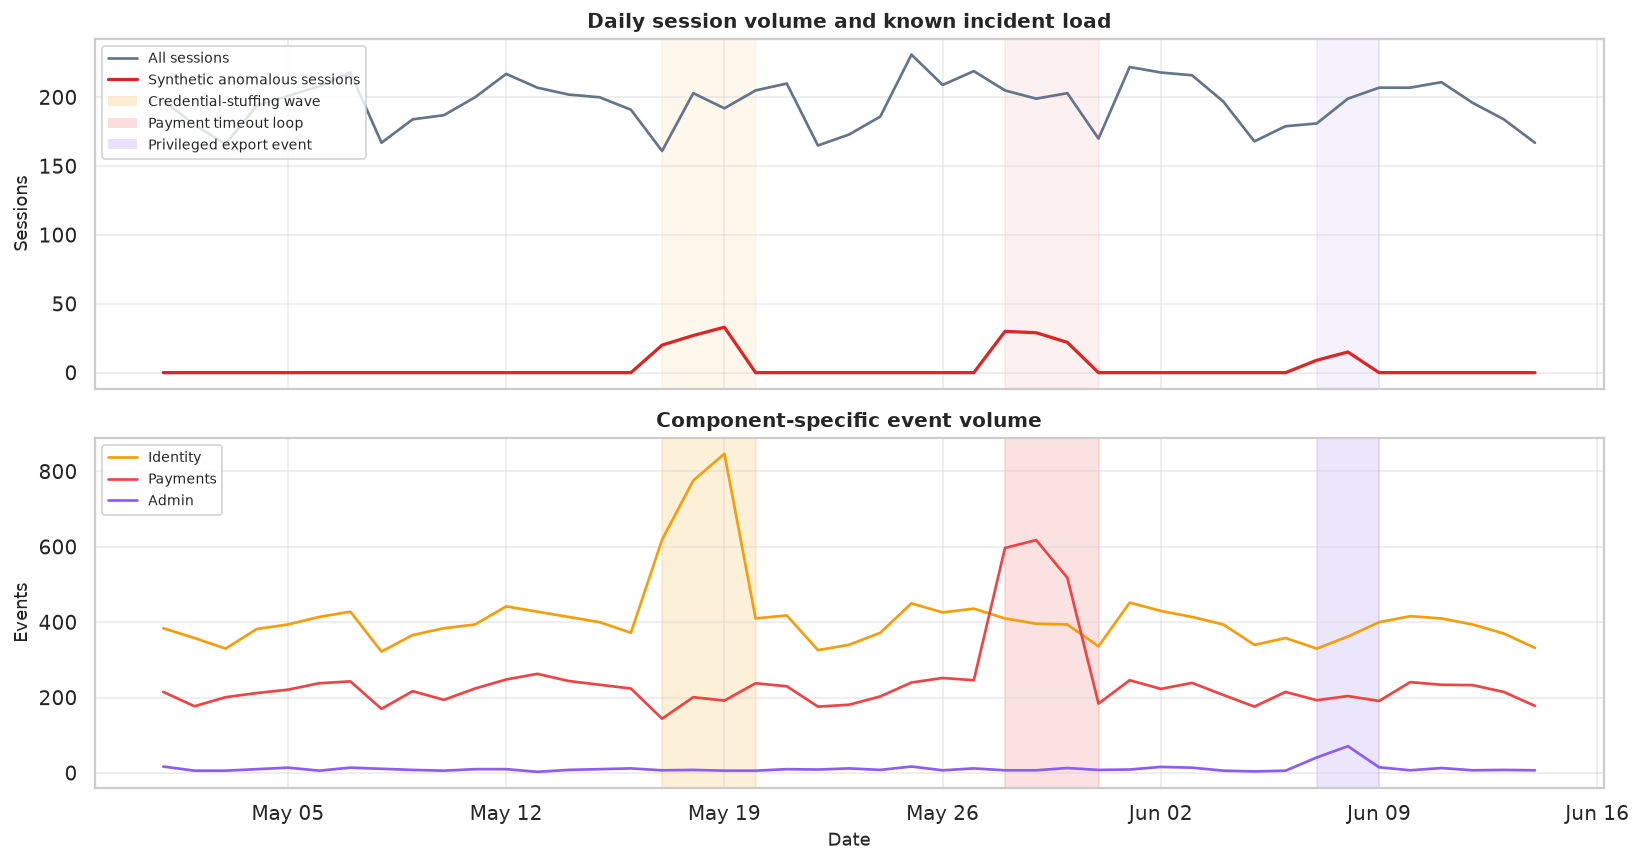

,event_name,component,severity,total_events,reference_events,monitoring_events
4,BROWSE_ITEM,catalog,info,15416,4802,10614
7,LOGIN_ATTEMPT,identity,info,9153,2720,6433
22,SESSION_END,gateway,info,8803,2729,6074
23,SESSION_START,gateway,info,8803,2729,6074
9,LOGIN_SUCCESS,identity,info,8321,2618,5703
12,PAYMENT_AUTH,payments,info,5130,1508,3622
6,CHECKOUT_START,checkout,info,4697,1457,3240
1,ADD_TO_CART,cart,info,4697,1457,3240
11,ORDER_CONFIRMED,orders,info,4650,1457,3193
14,PAYMENT_SUCCESS,payments,info,4650,1457,3193


In [3]:
# Section focus: 6. Event Volume and Template Frequencies.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

daily_counts = event_log.groupby(['date', 'anomaly_kind']).size().reset_index(name='events')
session_counts = session_log.groupby(['date', 'anomaly_kind']).size().reset_index(name='sessions')

template_counts = event_log.groupby(['event_name', 'component', 'severity']).agg(
    total_events=('event_name', 'size'),
    reference_events=('session_id', lambda x: reference_events['event_name'].eq(event_log.loc[x.index, 'event_name']).sum()),
).reset_index()
template_counts['monitoring_events'] = template_counts['total_events'] - template_counts['reference_events']
template_counts = template_counts.sort_values('total_events', ascending=False)

fig, axes = plt.subplots(2, 1, figsize=(12.8, 6.8), sharex=True)
normal_daily = session_log.groupby('date').agg(sessions=('session_id', 'size'), anomaly_sessions=('is_anomaly', 'sum')).reset_index()
axes[0].plot(normal_daily['date'], normal_daily['sessions'], color=PALETTE['baseline'], linewidth=1.5, label='All sessions')
axes[0].plot(normal_daily['date'], normal_daily['anomaly_sessions'], color=PALETTE['burst'], linewidth=1.8, label='Synthetic anomalous sessions')
axes[0].set_ylabel('Sessions')
axes[0].set_title('Daily session volume and known incident load')
add_incident_legend(axes[0], loc='upper left')

component_daily = event_log.groupby(['date', 'component']).size().reset_index(name='events')
for component, color in [('identity', PALETTE['incident_one']), ('payments', PALETTE['incident_two']), ('admin', PALETTE['incident_three'])]:
    data = component_daily[component_daily['component'].eq(component)]
    axes[1].plot(data['date'], data['events'], linewidth=1.5, label=component.title(), color=color)
shade_incidents(axes[1])
axes[1].set_ylabel('Events')
axes[1].set_xlabel('Date')
axes[1].set_title('Component-specific event volume')
axes[1].legend(loc='upper left')
axes[1].xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
for ax in axes:
    shade_incidents(ax)
    ax.grid(True, alpha=0.35)
plt.tight_layout()
plt.show()

smart_display(template_counts.head(12))


The first plot shows why sequence context matters. During the credential-stuffing period, identity events surge. During the payment-timeout incident, payment events surge. During the privileged-export incident, volume may be much smaller, but the sequence is qualitatively different.

A frequency detector is likely to catch the large bursts. It may miss rare but strategically important low-volume administrative anomalies unless those templates or transitions are assigned high operational importance.


## 7. Template Rarity Scores

We estimate smoothed template probabilities from the reference period. A monitoring event is surprising when it has low probability under that reference distribution.

For a template $e$, the rarity score is

$$
R(e) = -\log \hat p(e).
$$

This score is interpretable: each event template receives one rarity value. But it ignores ordering. `LOGIN_FAIL` may be common, and `MFA_CHALLENGE` may be common, while the repeated alternating pattern may be abnormal.


,event_name,monitoring_count,anomalous_share,reference_count,estimated_probability,rarity_score
10,MFA_CHALLENGE,184,100.0%,0,0.0020%,10.80
0,ACCOUNT_LOCKED,80,100.0%,0,0.0020%,10.80
5,BULK_EXPORT,24,100.0%,0,0.0020%,10.80
3,API_TOKEN_CREATED,20,100.0%,0,0.0020%,10.80
19,PERMISSION_CHANGE,48,50.0%,18,0.0756%,7.19
13,PAYMENT_RETRY,429,83.9%,51,0.2104%,6.16
15,PAYMENT_TIMEOUT,429,83.9%,51,0.2104%,6.16
20,REFUND_APPROVED,219,0.0%,88,0.3615%,5.62
8,LOGIN_FAIL,730,70.7%,102,0.4187%,5.48
2,ADMIN_LOGIN,291,8.2%,111,0.4554%,5.39


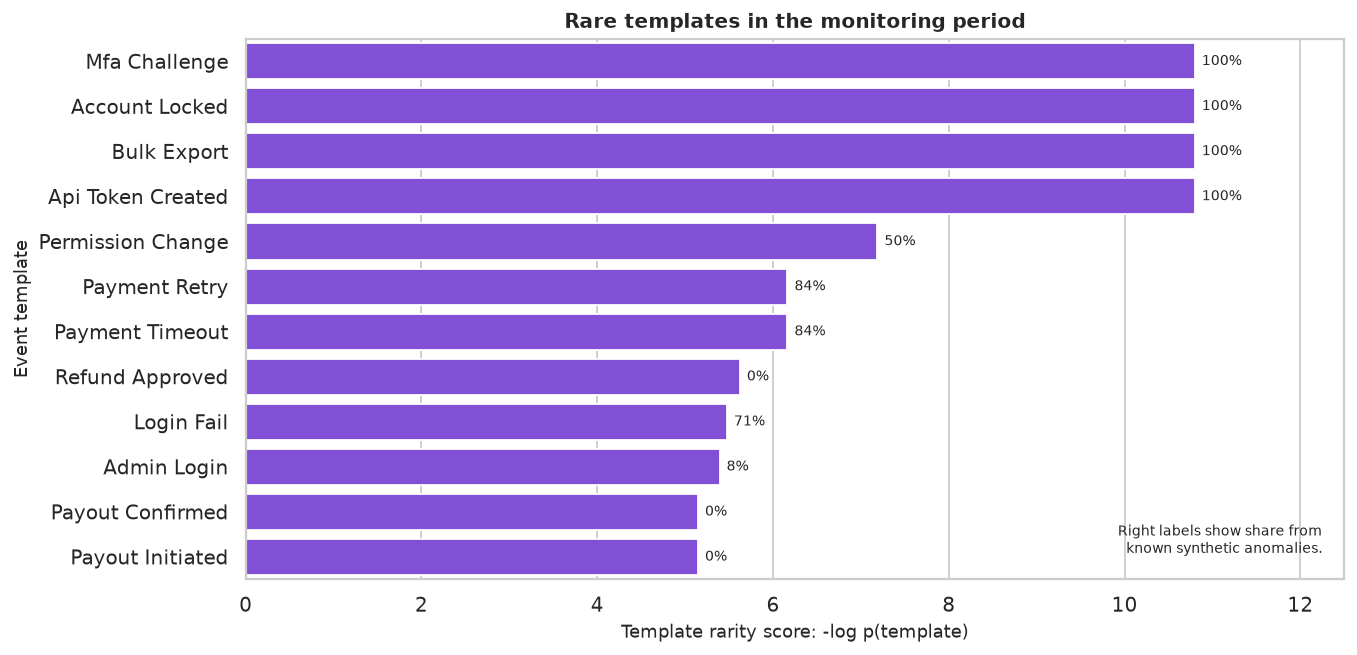

In [4]:
# Section focus: 7. Template Rarity Scores.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

alpha = 0.5
vocab = sorted(event_log['event_name'].unique())
ref_template_counts = reference_events['event_name'].value_counts().reindex(vocab, fill_value=0)
N_ref = ref_template_counts.sum()
template_prob = (ref_template_counts + alpha) / (N_ref + alpha * len(vocab))
template_rarity = (-np.log(template_prob)).rename('rarity_score')

template_rarity_table = pd.DataFrame({
    'event_name': template_rarity.index,
    'reference_count': ref_template_counts.values,
    'estimated_probability': template_prob.values,
    'rarity_score': template_rarity.values,
}).sort_values('rarity_score', ascending=False)

monitor_template_summary = monitor_events.groupby('event_name').agg(
    monitoring_count=('event_name', 'size'),
    anomalous_share=('is_anomaly', 'mean'),
).reset_index().merge(template_rarity_table, on='event_name', how='left')
monitor_template_summary = monitor_template_summary.sort_values(['rarity_score', 'monitoring_count'], ascending=[False, False])

smart_display(monitor_template_summary.head(12).style.format({
    'estimated_probability': '{:.4%}',
    'rarity_score': '{:.2f}',
    'anomalous_share': '{:.1%}',
}))

plot_data = monitor_template_summary.sort_values('rarity_score', ascending=False).head(12).copy()
plot_data['event_label'] = plot_data['event_name'].str.replace('_', ' ').str.title()
fig, ax = plt.subplots(figsize=(10.6, 5.2))
sns.barplot(data=plot_data, y='event_label', x='rarity_score', color=PALETTE['sequence'], ax=ax)
for patch, share in zip(ax.patches, plot_data['anomalous_share']):
    ax.text(patch.get_width() + 0.08, patch.get_y() + patch.get_height() / 2, f'{share:.0%}', va='center', fontsize=8)
ax.set_title('Rare templates in the monitoring period')
ax.set_xlabel('Template rarity score: -log p(template)')
ax.set_ylabel('Event template')
ax.set_xlim(0, plot_data['rarity_score'].max() + 1.7)
ax.text(0.98, 0.04, 'Right labels show share from\nknown synthetic anomalies.', transform=ax.transAxes, ha='right', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()


The most suspicious templates are the ones that either never appear or appear very rarely in the reference period. In this simulation, administrative events and lockout events are naturally rare. They should be interpreted with role, time, request lineage, and recent incident context before being labeled malicious.

The key limitation is that template rarity cannot tell whether a common event is occurring in the wrong sequence. That requires transition or sequence scoring.


## 8. Transition Models

A first-order transition model learns what usually follows what. It is still simple, but it captures order.

For transition $i \to j$, we estimate

$$
\hat p(j \mid i) = \frac{n_{ij} + \alpha}{n_i + \alpha |V|}.
$$

The transition surprise is

$$
T(i,j) = -\log \hat p(j \mid i).
$$

This score answers a useful operational question: “Which event pairs are unusual under normal execution paths?”


,from_event,to_event,monitoring_count,anomalous_share,transition_surprise,reference_count
14,LOGIN_FAIL,MFA_CHALLENGE,184,100.0%,5.43,0
12,LOGIN_FAIL,ACCOUNT_LOCKED,56,100.0%,5.43,0
24,PAYMENT_RETRY,SESSION_END,47,100.0%,4.84,0
31,PERMISSION_CHANGE,API_TOKEN_CREATED,20,100.0%,4.11,0
32,PERMISSION_CHANGE,BULK_EXPORT,4,100.0%,4.11,0
22,PAYMENT_AUTH,PAYMENT_TIMEOUT,429,83.9%,3.39,51
10,LOGIN_ATTEMPT,LOGIN_FAIL,730,70.7%,3.28,102
19,MFA_CHALLENGE,LOGIN_ATTEMPT,160,100.0%,3.22,0
0,ACCOUNT_LOCKED,SESSION_END,80,100.0%,3.22,0
8,BULK_EXPORT,SESSION_END,24,100.0%,3.22,0


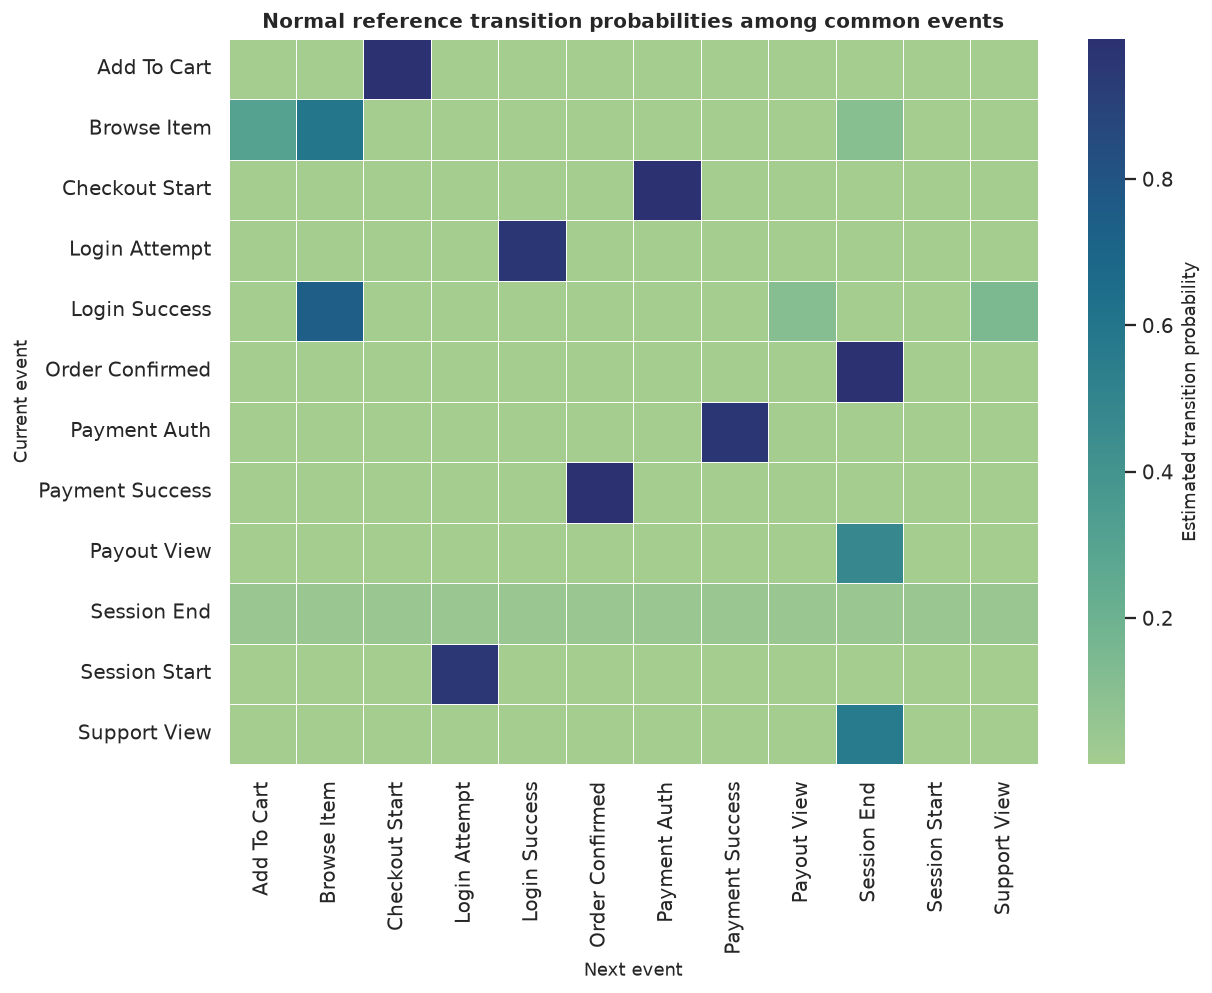

In [5]:
# Section focus: 8. Transition Models.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def transitions_from_sessions(sessions):
    """Carry out the transitions from sessions step used in the 12. Anomaly Detection for Logs, Events, and Sequences workflow.
    
    Parameters
    ----------
    sessions : object
        The sessions setting that controls the transitions from sessions calculation in this notebook.
    
    Returns
    -------
    object
        pandas.DataFrame containing the tabular result produced by this function.
    """
    rows = []
    for _, row in sessions.iterrows():
        seq = list(row['event_sequence'])
        for a, b in zip(seq[:-1], seq[1:]):
            rows.append({
                'session_id': row['session_id'],
                'from_event': a,
                'to_event': b,
                'anomaly_kind': row['anomaly_kind'],
                'is_anomaly': row['is_anomaly'],
                'day': row['day'],
                'date': row['date'],
            })
    return pd.DataFrame(rows)

reference_transitions = transitions_from_sessions(reference_sessions)
monitor_transitions = transitions_from_sessions(monitor_sessions)

transition_count = reference_transitions.groupby(['from_event', 'to_event']).size().rename('n_ij')
from_count = reference_transitions.groupby('from_event').size().rename('n_i')

transition_rows = []
for from_event in vocab:
    n_i = from_count.get(from_event, 0)
    for to_event in vocab:
        n_ij = transition_count.get((from_event, to_event), 0)
        prob = (n_ij + alpha) / (n_i + alpha * len(vocab))
        transition_rows.append({'from_event': from_event, 'to_event': to_event, 'transition_probability': prob, 'transition_surprise': -np.log(prob), 'reference_count': n_ij})
transition_model = pd.DataFrame(transition_rows)

monitor_transition_scored = monitor_transitions.merge(transition_model, on=['from_event', 'to_event'], how='left')
rare_transition_table = monitor_transition_scored.groupby(['from_event', 'to_event']).agg(
    monitoring_count=('session_id', 'size'),
    anomalous_share=('is_anomaly', 'mean'),
    transition_surprise=('transition_surprise', 'mean'),
    reference_count=('reference_count', 'mean'),
).reset_index().sort_values(['transition_surprise', 'monitoring_count'], ascending=[False, False])

smart_display(rare_transition_table.head(14).style.format({
    'transition_surprise': '{:.2f}',
    'anomalous_share': '{:.1%}',
    'reference_count': '{:.0f}',
}))

common_events = reference_events['event_name'].value_counts().head(12).index.tolist()
heat = transition_model[transition_model['from_event'].isin(common_events) & transition_model['to_event'].isin(common_events)].copy()
heat['from_label'] = heat['from_event'].str.replace('_', ' ').str.title()
heat['to_label'] = heat['to_event'].str.replace('_', ' ').str.title()
transition_matrix = heat.pivot(index='from_label', columns='to_label', values='transition_probability')

fig, ax = plt.subplots(figsize=(9.8, 7.8))
sns.heatmap(transition_matrix, cmap='crest', linewidths=0.4, linecolor='white', cbar_kws={'label': 'Estimated transition probability'}, ax=ax)
ax.set_title('Normal reference transition probabilities among common events')
ax.set_xlabel('Next event')
ax.set_ylabel('Current event')
plt.tight_layout()
plt.show()


The rare-transition table is often more useful than a raw anomaly score. It gives analysts concrete questions:

- Why did an account lock appear after this sequence of login failures?
- Why did payment retries loop instead of resolving or failing cleanly?
- Why did permission changes precede a bulk export?

The heatmap shows the opposite view: normal execution paths. If production software changes, this heatmap can also reveal instrumentation drift because previously common paths may disappear or new paths may emerge.


## 9. Session-Level Sequence Likelihood

A session can contain several moderately surprising transitions. Instead of alerting on every transition, we aggregate transition surprise into a session score.

For session $s$:

$$
A_s = \frac{1}{L_s - 1}\sum_{k=2}^{L_s} T(e_{s,k-1}, e_{s,k}).
$$

We also include the maximum transition surprise, rare-template burden, and session length. The goal is to rank sessions and explain why they were ranked.


,model,threshold_source,roc_auc,average_precision,monitoring_alert_rate,alert_precision,incident_recall
0,Transparent Markov/session score,99.5th percentile of reference scores,0.999,0.958,2.47%,84.00%,68.11%


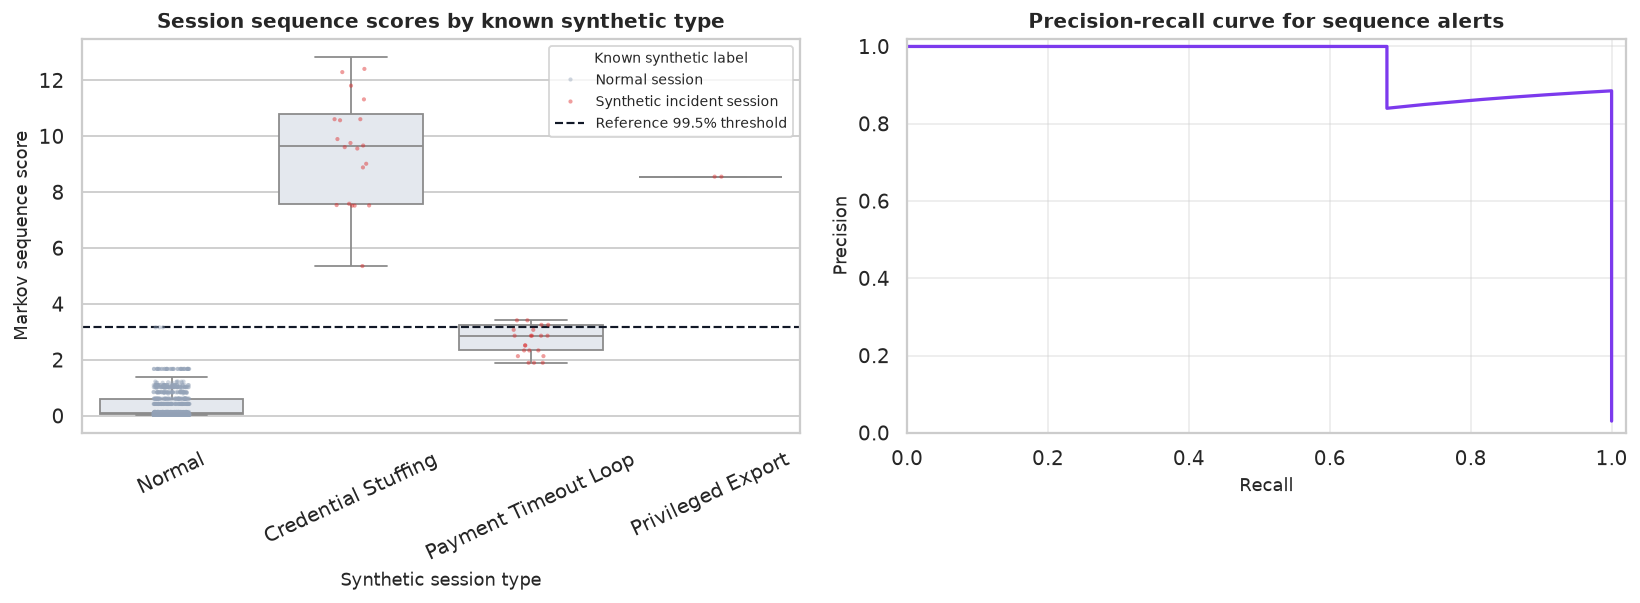

,session_id,date,account_segment,anomaly_kind,sequence_length,markov_sequence_score,unseen_transition_count,rare_template_count,sequence_preview
3424,S03475,2026-05-18 00:00:00,consumer,credential_stuffing,26,12.85,15.000000,8.000000,SESSION_START -> LOGIN_ATTEMPT -> LOGIN_FAIL -> MFA_CHALLENGE -> LOGIN_ATTEMPT -> LOGIN_FAIL -> MFA_CHALLENGE -> LOGIN_ATTEMPT -> LOGIN_FAIL -> MFA_CHALLENGE -> ...
3537,S03487,2026-05-19 00:00:00,consumer,credential_stuffing,22,12.41,12.000000,6.000000,SESSION_START -> LOGIN_ATTEMPT -> LOGIN_FAIL -> MFA_CHALLENGE -> LOGIN_ATTEMPT -> LOGIN_FAIL -> MFA_CHALLENGE -> LOGIN_ATTEMPT -> LOGIN_FAIL -> MFA_CHALLENGE -> ...
3183,S03180,2026-05-17 00:00:00,consumer,credential_stuffing,24,12.32,12.000000,6.000000,SESSION_START -> LOGIN_ATTEMPT -> LOGIN_FAIL -> MFA_CHALLENGE -> LOGIN_ATTEMPT -> LOGIN_FAIL -> MFA_CHALLENGE -> LOGIN_ATTEMPT -> LOGIN_FAIL -> MFA_CHALLENGE -> ...
3278,S03145,2026-05-17 00:00:00,consumer,credential_stuffing,22,12.29,11.000000,6.000000,SESSION_START -> LOGIN_ATTEMPT -> LOGIN_FAIL -> MFA_CHALLENGE -> LOGIN_ATTEMPT -> LOGIN_FAIL -> MFA_CHALLENGE -> LOGIN_ATTEMPT -> LOGIN_FAIL -> MFA_CHALLENGE -> ...
3348,S03394,2026-05-18 00:00:00,consumer,credential_stuffing,26,12.25,12.000000,6.000000,SESSION_START -> LOGIN_ATTEMPT -> LOGIN_FAIL -> LOGIN_ATTEMPT -> LOGIN_FAIL -> MFA_CHALLENGE -> LOGIN_ATTEMPT -> LOGIN_FAIL -> MFA_CHALLENGE -> LOGIN_ATTEMPT -> ...
3220,S03165,2026-05-17 00:00:00,internal,credential_stuffing,26,12.25,12.000000,6.000000,SESSION_START -> LOGIN_ATTEMPT -> LOGIN_FAIL -> LOGIN_ATTEMPT -> LOGIN_FAIL -> MFA_CHALLENGE -> LOGIN_ATTEMPT -> LOGIN_FAIL -> MFA_CHALLENGE -> LOGIN_ATTEMPT -> ...
3336,S03286,2026-05-18 00:00:00,consumer,credential_stuffing,17,11.81,10.000000,5.000000,SESSION_START -> LOGIN_ATTEMPT -> LOGIN_FAIL -> MFA_CHALLENGE -> LOGIN_ATTEMPT -> LOGIN_FAIL -> MFA_CHALLENGE -> LOGIN_ATTEMPT -> LOGIN_FAIL -> MFA_CHALLENGE -> ...
3614,S03643,2026-05-19 00:00:00,consumer,credential_stuffing,17,11.66,9.000000,5.000000,SESSION_START -> LOGIN_ATTEMPT -> LOGIN_FAIL -> MFA_CHALLENGE -> LOGIN_ATTEMPT -> LOGIN_FAIL -> MFA_CHALLENGE -> LOGIN_ATTEMPT -> LOGIN_FAIL -> MFA_CHALLENGE -> ...
3648,S03620,2026-05-19 00:00:00,merchant,credential_stuffing,21,11.55,10.000000,5.000000,SESSION_START -> LOGIN_ATTEMPT -> LOGIN_FAIL -> MFA_CHALLENGE -> LOGIN_ATTEMPT -> LOGIN_FAIL -> MFA_CHALLENGE -> LOGIN_ATTEMPT -> LOGIN_FAIL -> MFA_CHALLENGE -> ...
3126,S03172,2026-05-17 00:00:00,consumer,credential_stuffing,21,11.55,10.000000,5.000000,SESSION_START -> LOGIN_ATTEMPT -> LOGIN_FAIL -> MFA_CHALLENGE -> LOGIN_ATTEMPT -> LOGIN_FAIL -> MFA_CHALLENGE -> LOGIN_ATTEMPT -> LOGIN_FAIL -> LOGIN_ATTEMPT -> ...


In [6]:
# Section focus: 9. Session-Level Sequence Likelihood.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def score_session(row):
    """Score session for the 12. Anomaly Detection for Logs, Events, and Sequences workflow.
    
    Parameters
    ----------
    row : object
        Single data-frame row representing one unit in the current decision example.
    
    Returns
    -------
    object
        pandas.Series containing the computed values for downstream cells.
    """
    seq = list(row['event_sequence'])
    template_scores = [template_rarity.get(event, -np.log(alpha / (N_ref + alpha * len(vocab)))) for event in seq]
    transition_scores = []
    unseen_transitions = 0
    for a, b in zip(seq[:-1], seq[1:]):
        match = transition_model[(transition_model['from_event'].eq(a)) & (transition_model['to_event'].eq(b))].iloc[0]
        transition_scores.append(float(match['transition_surprise']))
        unseen_transitions += int(match['reference_count'] == 0)
    return pd.Series({
        'mean_template_rarity': float(np.mean(template_scores)),
        'max_template_rarity': float(np.max(template_scores)),
        'mean_transition_surprise': float(np.mean(transition_scores)) if transition_scores else 0.0,
        'max_transition_surprise': float(np.max(transition_scores)) if transition_scores else 0.0,
        'unseen_transition_count': unseen_transitions,
        'rare_template_count': int(np.sum(np.array(template_scores) > np.quantile(template_rarity.values, 0.80))),
    })

session_features = session_log.join(session_log.apply(score_session, axis=1))
feature_cols = ['mean_template_rarity', 'max_template_rarity', 'mean_transition_surprise', 'max_transition_surprise', 'unseen_transition_count', 'rare_template_count', 'sequence_length']
reference_feature_rows = session_features[session_features['day'] < 14]

# Robustly standardize by reference behavior so each component is on a comparable scale.
for col in feature_cols:
    z, center, scale = robust_zscore(reference_feature_rows[col].to_numpy())
    session_features[f'z_{col}'], _, _ = robust_zscore(session_features[col].to_numpy(), center=center, scale=scale)

z_cols = [f'z_{col}' for col in feature_cols]
session_features['markov_sequence_score'] = session_features[z_cols].clip(lower=0, upper=25).mean(axis=1)
threshold = session_features.loc[session_features['day'] < 14, 'markov_sequence_score'].quantile(0.995)
session_features['markov_alert'] = session_features['markov_sequence_score'] >= threshold

eval_monitor = session_features[session_features['day'] >= 14].copy()
auc = roc_auc_score(eval_monitor['is_anomaly'], eval_monitor['markov_sequence_score'])
ap = average_precision_score(eval_monitor['is_anomaly'], eval_monitor['markov_sequence_score'])
alert_rate = eval_monitor['markov_alert'].mean()
precision = eval_monitor.loc[eval_monitor['markov_alert'], 'is_anomaly'].mean()
recall = eval_monitor.loc[eval_monitor['is_anomaly'], 'markov_alert'].mean()

metrics = pd.DataFrame([{
    'model': 'Transparent Markov/session score',
    'threshold_source': '99.5th percentile of reference scores',
    'roc_auc': auc,
    'average_precision': ap,
    'monitoring_alert_rate': alert_rate,
    'alert_precision': precision,
    'incident_recall': recall,
}])
smart_display(metrics.style.format({
    'roc_auc': '{:.3f}',
    'average_precision': '{:.3f}',
    'monitoring_alert_rate': '{:.2%}',
    'alert_precision': '{:.2%}',
    'incident_recall': '{:.2%}',
}))

fig, axes = plt.subplots(1, 2, figsize=(12.8, 4.8))
plot_scores = eval_monitor.copy()
plot_scores['session_type'] = plot_scores['anomaly_kind'].str.replace('_', ' ').str.title()
plot_scores['known_label'] = np.where(plot_scores['is_anomaly'], 'Synthetic incident session', 'Normal session')
sns.boxplot(data=plot_scores, x='session_type', y='markov_sequence_score', color='#e2e8f0', ax=axes[0], showfliers=False)
sns.stripplot(data=plot_scores.sample(min(1100, len(plot_scores)), random_state=RANDOM_SEED), x='session_type', y='markov_sequence_score', hue='known_label', palette={'Normal session': PALETTE['normal'], 'Synthetic incident session': PALETTE['burst']}, size=2.3, alpha=0.45, ax=axes[0])
axes[0].axhline(threshold, color=PALETTE['threshold'], linestyle='--', linewidth=1.2, label='Reference 99.5% threshold')
axes[0].set_title('Session sequence scores by known synthetic type')
axes[0].set_xlabel('Synthetic session type')
axes[0].set_ylabel('Markov sequence score')
axes[0].tick_params(axis='x', rotation=25)
axes[0].legend(title='Known synthetic label', loc='upper right')

precision_curve, recall_curve, pr_thresholds = precision_recall_curve(eval_monitor['is_anomaly'], eval_monitor['markov_sequence_score'])
axes[1].plot(recall_curve, precision_curve, color=PALETTE['sequence'], linewidth=1.8)
axes[1].set_title('Precision-recall curve for sequence alerts')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_xlim(0, 1.02)
axes[1].set_ylim(0, 1.02)
axes[1].grid(True, alpha=0.35)
plt.tight_layout()
plt.show()

top_markov_alerts = eval_monitor.sort_values('markov_sequence_score', ascending=False).head(10).copy()
top_markov_alerts['sequence_preview'] = top_markov_alerts['event_sequence'].apply(lambda seq: ' -> '.join(seq[:10]) + (' -> ...' if len(seq) > 10 else ''))
smart_display(top_markov_alerts[['session_id', 'date', 'account_segment', 'anomaly_kind', 'sequence_length', 'markov_sequence_score', 'unseen_transition_count', 'rare_template_count', 'sequence_preview']].style.format({'markov_sequence_score': '{:.2f}'}), max_width='520px')


The sequence score is intentionally transparent. It tells us whether the session is strange because it contains rare templates, unseen transitions, long repeated loops, or a combination of these. That makes it useful for analyst queues and post-incident review.

The precision-recall curve also reminds us that alert thresholds are decision choices. A fraud or reliability team may tolerate more false positives during an active incident, while an executive escalation queue may require much higher precision.


## 10. N-Gram Count Models

A Markov model only looks one step back. A practical alternative is to convert each session into a bag of event n-grams. For example, the sequence

`LOGIN_ATTEMPT -> LOGIN_FAIL -> MFA_CHALLENGE`

contains unigrams, bigrams, and trigrams. We can fit an unsupervised model on normal reference sessions and score monitoring sessions by how isolated their n-gram patterns are.

This is not as expressive as a neural language model, but it is fast, inspectable, and often useful as a baseline.


,model,roc_auc,average_precision,alert_rate,alert_precision,incident_recall
0,Markov/session score,0.999,0.958,2.47%,84.00%,68.11%
1,N-gram Isolation Forest,0.957,0.363,0.89%,62.96%,18.38%


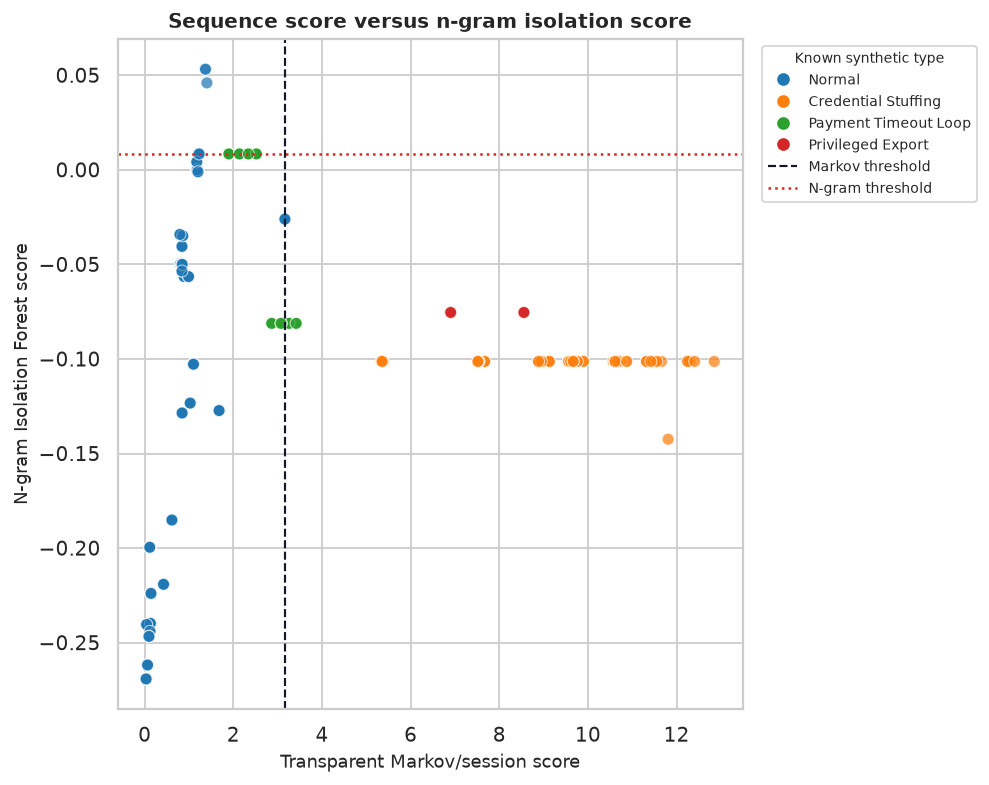

In [7]:
# Section focus: 10. N-Gram Count Models.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def sequence_to_document(seq):
    """Carry out the sequence to document step used in the 12. Anomaly Detection for Logs, Events, and Sequences workflow.
    
    Parameters
    ----------
    seq : object
        The seq setting that controls the sequence to document calculation in this notebook.
    
    Returns
    -------
    object
        Intermediate result produced by the sequence to document calculation and reused by later cells.
    """
    return ' '.join(seq)

session_features['sequence_document'] = session_features['event_sequence'].apply(sequence_to_document)
train_docs = session_features.loc[session_features['day'] < 14, 'sequence_document']
all_docs = session_features['sequence_document']

vectorizer = CountVectorizer(token_pattern=r'[^\s]+', ngram_range=(1, 3), min_df=2)
X_train = vectorizer.fit_transform(train_docs)
X_all = vectorizer.transform(all_docs)

ngram_detector = IsolationForest(
    n_estimators=220,
    contamination=0.015,
    random_state=RANDOM_SEED,
    n_jobs=-1,
)
ngram_detector.fit(X_train)
session_features['ngram_isolation_score'] = -ngram_detector.decision_function(X_all)
ngram_threshold = session_features.loc[session_features['day'] < 14, 'ngram_isolation_score'].quantile(0.995)
session_features['ngram_alert'] = session_features['ngram_isolation_score'] >= ngram_threshold

eval_monitor = session_features[session_features['day'] >= 14].copy()
model_compare = pd.DataFrame([
    {
        'model': 'Markov/session score',
        'roc_auc': roc_auc_score(eval_monitor['is_anomaly'], eval_monitor['markov_sequence_score']),
        'average_precision': average_precision_score(eval_monitor['is_anomaly'], eval_monitor['markov_sequence_score']),
        'alert_rate': eval_monitor['markov_alert'].mean(),
        'alert_precision': eval_monitor.loc[eval_monitor['markov_alert'], 'is_anomaly'].mean(),
        'incident_recall': eval_monitor.loc[eval_monitor['is_anomaly'], 'markov_alert'].mean(),
    },
    {
        'model': 'N-gram Isolation Forest',
        'roc_auc': roc_auc_score(eval_monitor['is_anomaly'], eval_monitor['ngram_isolation_score']),
        'average_precision': average_precision_score(eval_monitor['is_anomaly'], eval_monitor['ngram_isolation_score']),
        'alert_rate': eval_monitor['ngram_alert'].mean(),
        'alert_precision': eval_monitor.loc[eval_monitor['ngram_alert'], 'is_anomaly'].mean(),
        'incident_recall': eval_monitor.loc[eval_monitor['is_anomaly'], 'ngram_alert'].mean(),
    },
])
smart_display(model_compare.style.format({
    'roc_auc': '{:.3f}',
    'average_precision': '{:.3f}',
    'alert_rate': '{:.2%}',
    'alert_precision': '{:.2%}',
    'incident_recall': '{:.2%}',
}))

fig, ax = plt.subplots(figsize=(7.8, 6.2))
plot_eval = eval_monitor.copy()
plot_eval['known_type'] = plot_eval['anomaly_kind'].str.replace('_', ' ').str.title()
type_order = ['Normal', 'Credential Stuffing', 'Payment Timeout Loop', 'Privileged Export']
type_palette = dict(zip(type_order, sns.color_palette('tab10', n_colors=len(type_order))))
sns.scatterplot(
    data=plot_eval,
    x='markov_sequence_score',
    y='ngram_isolation_score',
    hue='known_type',
    palette=type_palette,
    s=44,
    alpha=0.72,
    legend=False,
    ax=ax,
)
ax.axvline(threshold, color=PALETTE['threshold'], linestyle='--', linewidth=1.2, label='Markov threshold')
ax.axhline(ngram_threshold, color=PALETTE['burst'], linestyle=':', linewidth=1.4, label='N-gram threshold')
ax.set_title('Sequence score versus n-gram isolation score')
ax.set_xlabel('Transparent Markov/session score')
ax.set_ylabel('N-gram Isolation Forest score')
legend_handles = [
    Line2D([0], [0], marker='o', color='white', markerfacecolor=type_palette[label], markeredgecolor=type_palette[label], markersize=6, label=label)
    for label in type_order
]
legend_handles += [
    Line2D([0], [0], color=PALETTE['threshold'], linestyle='--', linewidth=1.2, label='Markov threshold'),
    Line2D([0], [0], color=PALETTE['burst'], linestyle=':', linewidth=1.4, label='N-gram threshold'),
]
ax.legend(handles=legend_handles, title='Known synthetic type', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


The two detectors do not have to agree. That disagreement is useful.

- A Markov score is sensitive to unlikely event order and rare transitions.
- An n-gram count model is sensitive to repeated motifs and local subsequences.
- A session that both models flag is a stronger candidate for review.
- A session that only one model flags should be routed with more context rather than automatically escalated.

This kind of model disagreement is not a nuisance. It is diagnostic information.


## 11. Burst Detection for Event Streams

Sequence scores are session-level. Operational incidents often also create aggregate bursts. Let $Y_{e,h}$ be the count of event template $e$ in hour $h$. A simple Pearson-style residual is

$$
B_{e,h} = \frac{Y_{e,h} - \hat \lambda_e}{\sqrt{\hat \lambda_e + 1}},
$$

where $\hat \lambda_e$ is the reference hourly mean count for template $e$. This is not a full seasonal model, but it is a clear baseline for identifying event types with abnormal volume.


,hour,event_name,count,expected_count,burst_residual,burst_alert
11033,2026-05-19 10:00,LOGIN_FAIL,35,0.30,30.38,True
11158,2026-05-19 15:00,LOGIN_FAIL,22,0.30,19.00,True
16665,2026-05-28 19:00,PAYMENT_TIMEOUT,18,0.15,16.63,True
16663,2026-05-28 19:00,PAYMENT_RETRY,18,0.15,16.63,True
17163,2026-05-29 15:00,PAYMENT_RETRY,18,0.15,16.63,True
17165,2026-05-29 15:00,PAYMENT_TIMEOUT,18,0.15,16.63,True
11233,2026-05-19 18:00,LOGIN_FAIL,19,0.30,16.37,True
10658,2026-05-18 19:00,LOGIN_FAIL,19,0.30,16.37,True
10058,2026-05-17 19:00,LOGIN_FAIL,19,0.30,16.37,True
9908,2026-05-17 13:00,LOGIN_FAIL,18,0.30,15.49,True


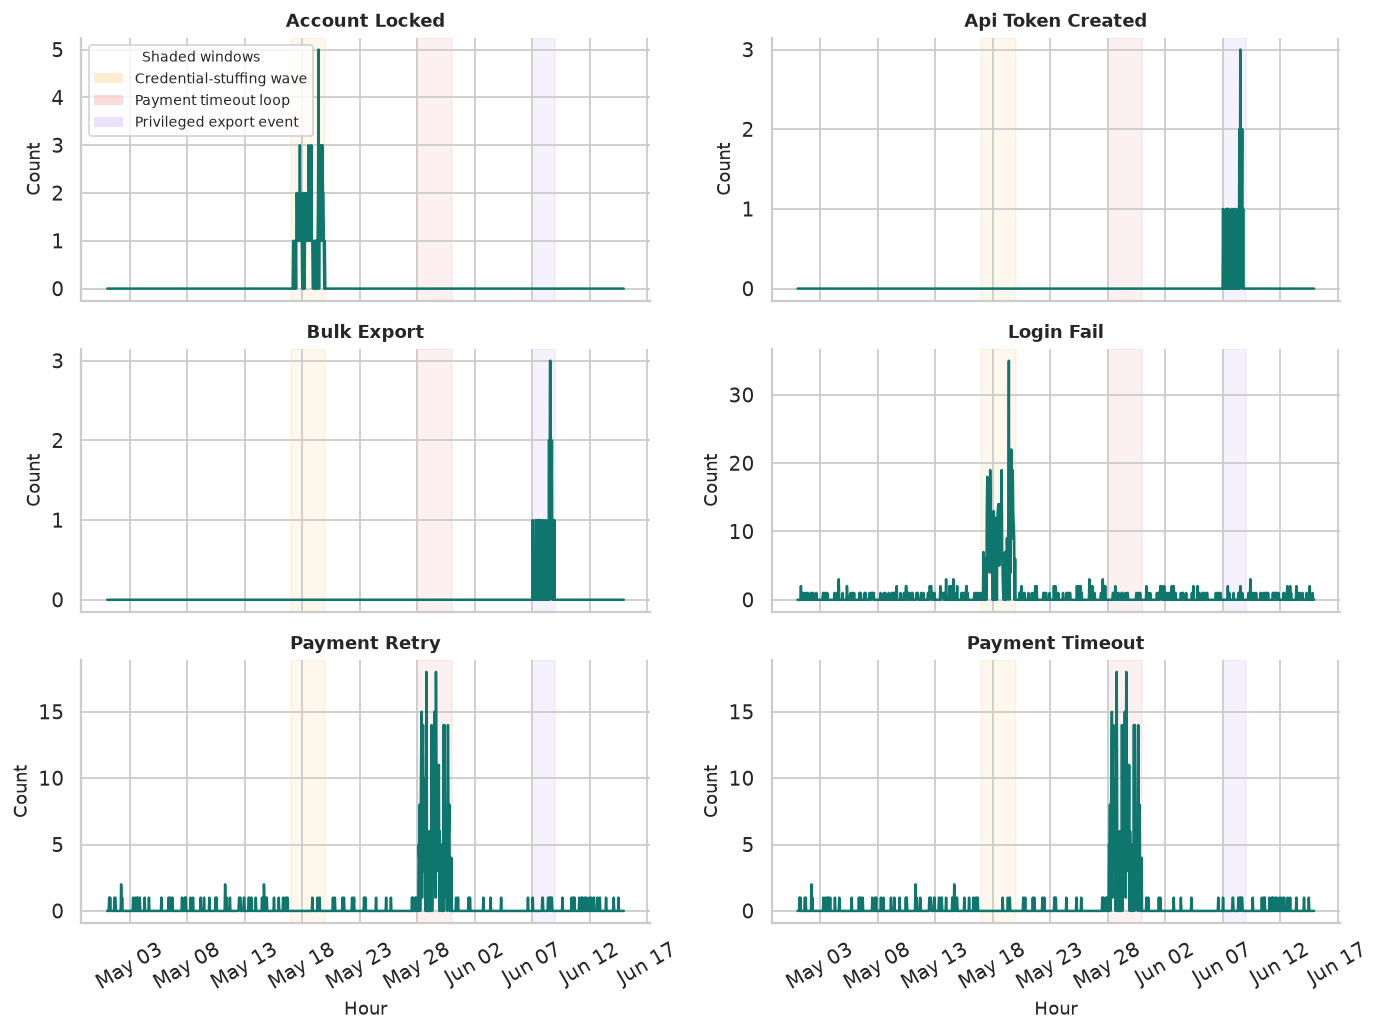

In [8]:
# Section focus: 11. Burst Detection for Event Streams.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

hourly_event_counts = event_log.groupby(['hour', 'event_name']).size().reset_index(name='count')
all_hours = pd.date_range(event_log['hour'].min(), event_log['hour'].max(), freq='h')
full_index = pd.MultiIndex.from_product([all_hours, vocab], names=['hour', 'event_name'])
hourly_event_counts = hourly_event_counts.set_index(['hour', 'event_name']).reindex(full_index, fill_value=0).reset_index()
hourly_event_counts['date'] = hourly_event_counts['hour'].dt.normalize()
hourly_event_counts['day'] = (hourly_event_counts['date'] - event_log['date'].min()).dt.days

baseline_hourly = hourly_event_counts[hourly_event_counts['day'] < 14]
lambda_by_event = baseline_hourly.groupby('event_name')['count'].mean().reindex(vocab).clip(lower=0.05)
hourly_event_counts['expected_count'] = hourly_event_counts['event_name'].map(lambda_by_event)
hourly_event_counts['burst_residual'] = (hourly_event_counts['count'] - hourly_event_counts['expected_count']) / np.sqrt(hourly_event_counts['expected_count'] + 1)
hourly_event_counts['burst_alert'] = hourly_event_counts['burst_residual'] >= 5.0

burst_table = hourly_event_counts[hourly_event_counts['day'] >= 14].sort_values('burst_residual', ascending=False).head(14).copy()
burst_table['hour'] = burst_table['hour'].dt.strftime('%Y-%m-%d %H:%M')
smart_display(burst_table[['hour', 'event_name', 'count', 'expected_count', 'burst_residual', 'burst_alert']].style.format({
    'expected_count': '{:.2f}',
    'burst_residual': '{:.2f}',
}))

selected_events = ['LOGIN_FAIL', 'ACCOUNT_LOCKED', 'PAYMENT_TIMEOUT', 'PAYMENT_RETRY', 'API_TOKEN_CREATED', 'BULK_EXPORT']
plot_hourly = hourly_event_counts[hourly_event_counts['event_name'].isin(selected_events)].copy()
plot_hourly['event_label'] = plot_hourly['event_name'].str.replace('_', ' ').str.title()

grid = sns.FacetGrid(plot_hourly, col='event_label', col_wrap=2, height=2.7, aspect=2.0, sharey=False)
grid.map_dataframe(sns.lineplot, x='hour', y='count', color=PALETTE['monitor'], linewidth=1.4)
for ax in grid.axes.flatten():
    shade_incidents(ax)
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=5))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    ax.tick_params(axis='x', rotation=30)
    ax.set_xlabel('Hour')
    ax.set_ylabel('Count')
grid.set_titles('{col_name}')
# Add one compact legend for the shaded incident periods.
grid.axes.flatten()[0].legend(handles=incident_legend_handles(), loc='upper left', title='Shaded windows')
plt.tight_layout()
plt.show()


Burst detection catches incidents that create many similar events in a short time. This is especially effective for credential stuffing and retry loops. It is less reliable for quiet but high-impact administrative events.

This is why session-level and aggregate detectors should be combined. Session scores ask, “Is this path unusual?” Burst scores ask, “Is this event type surging?” A strong incident process usually needs both views.


## 12. Alert Triage: Combining Sequence and Burst Evidence

A decision system should not send every strange session to the same queue. We combine three signals:

- Markov sequence alert.
- N-gram sequence alert.
- Burst context in the session hour.

The resulting review state is intentionally operational rather than purely statistical.


,anomaly_kind,review_state,sessions,anomaly_rate,mean_markov_score,mean_ngram_score,mean_burst_residual
0,credential_stuffing,Incident response: sequence plus burst evidence,67,100.0%,9.53,-0.10,12.83
1,credential_stuffing,Low-priority sequence review,13,100.0%,8.25,-0.10,4.38
5,normal,Routine monitoring,4473,0.0%,0.35,-0.21,2.13
2,normal,Aggregate burst monitoring,1372,0.0%,0.33,-0.21,8.16
4,normal,Low-priority sequence review,33,0.0%,2.35,-0.01,2.05
3,normal,Incident response: sequence plus burst evidence,11,0.0%,2.12,-0.00,7.39
7,payment_timeout_loop,Incident response: sequence plus burst evidence,44,100.0%,2.74,-0.03,10.87
6,payment_timeout_loop,Aggregate burst monitoring,18,100.0%,2.94,-0.08,10.36
8,payment_timeout_loop,Low-priority sequence review,12,100.0%,2.38,-0.01,3.94
9,payment_timeout_loop,Routine monitoring,7,100.0%,2.99,-0.08,3.24


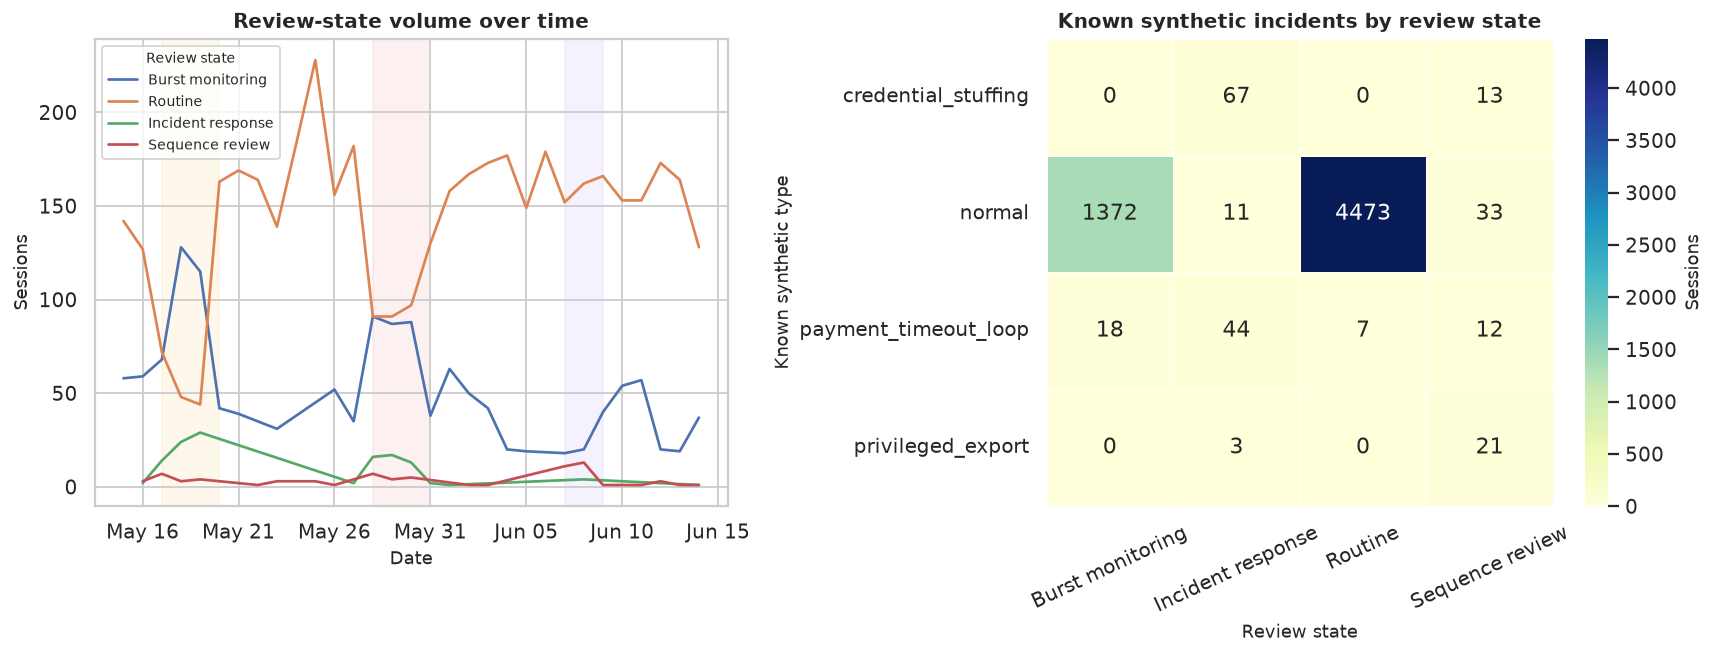

In [9]:
# Section focus: 12. Alert Triage: Combining Sequence and Burst Evidence.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

# Attach burst context to each session using the maximum burst residual in that session hour.
session_features['hour'] = session_features['start_time'].dt.floor('h')
hour_context = hourly_event_counts.groupby('hour').agg(
    max_burst_residual=('burst_residual', 'max'),
    burst_event_count=('burst_alert', 'sum'),
).reset_index()
session_features = session_features.merge(hour_context, on='hour', how='left')
session_features['burst_context_alert'] = session_features['max_burst_residual'] >= 5.0


def assign_review_state(row):
    """Carry out the assign review state step used in the 12. Anomaly Detection for Logs, Events, and Sequences workflow.
    
    Parameters
    ----------
    row : object
        Single data-frame row representing one unit in the current decision example.
    
    Returns
    -------
    object
        Text or structured language-model artifact produced by the assign review state workflow.
    """
    sequence_votes = int(row['markov_alert']) + int(row['ngram_alert'])
    if sequence_votes >= 1 and row['burst_context_alert']:
        return 'Incident response: sequence plus burst evidence'
    if sequence_votes >= 2:
        return 'High-priority session review'
    if row['burst_context_alert']:
        return 'Aggregate burst monitoring'
    if sequence_votes == 1:
        return 'Low-priority sequence review'
    return 'Routine monitoring'

session_features['review_state'] = session_features.apply(assign_review_state, axis=1)
review_summary = session_features[session_features['day'] >= 14].groupby(['anomaly_kind', 'review_state']).agg(
    sessions=('session_id', 'size'),
    anomaly_rate=('is_anomaly', 'mean'),
    mean_markov_score=('markov_sequence_score', 'mean'),
    mean_ngram_score=('ngram_isolation_score', 'mean'),
    mean_burst_residual=('max_burst_residual', 'mean'),
).reset_index().sort_values(['anomaly_kind', 'sessions'], ascending=[True, False])

smart_display(review_summary.style.format({
    'anomaly_rate': '{:.1%}',
    'mean_markov_score': '{:.2f}',
    'mean_ngram_score': '{:.2f}',
    'mean_burst_residual': '{:.2f}',
}))

state_label_map = {
    'Incident response: sequence plus burst evidence': 'Incident response',
    'High-priority session review': 'High-priority review',
    'Aggregate burst monitoring': 'Burst monitoring',
    'Low-priority sequence review': 'Sequence review',
    'Routine monitoring': 'Routine',
}
plot_states = session_features[session_features['day'] >= 14].copy()
plot_states['review_state_short'] = plot_states['review_state'].map(state_label_map)

fig, axes = plt.subplots(1, 2, figsize=(13.4, 5.2))
state_counts = plot_states.groupby(['date', 'review_state_short']).size().reset_index(name='sessions')
sns.lineplot(data=state_counts, x='date', y='sessions', hue='review_state_short', linewidth=1.5, ax=axes[0])
shade_incidents(axes[0])
axes[0].set_title('Review-state volume over time')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Sessions')
axes[0].legend(title='Review state', loc='upper left')
axes[0].xaxis.set_major_locator(mdates.DayLocator(interval=5))
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))

confusion_like = plot_states.pivot_table(
    index='anomaly_kind',
    columns='review_state_short',
    values='session_id',
    aggfunc='count',
    fill_value=0,
)
sns.heatmap(confusion_like, annot=True, fmt='d', cmap='YlGnBu', linewidths=0.5, linecolor='white', cbar_kws={'label': 'Sessions'}, ax=axes[1])
axes[1].set_title('Known synthetic incidents by review state')
axes[1].set_xlabel('Review state')
axes[1].set_ylabel('Known synthetic type')
axes[1].tick_params(axis='x', rotation=25)
plt.tight_layout()
plt.show()


The triage table is the business object. It separates several operational states:

- **Incident response** when unusual sessions happen during a burst.
- **High-priority review** when both sequence models agree even without a large burst.
- **Aggregate burst monitoring** when volume is abnormal but individual sessions are not especially strange.
- **Low-priority sequence review** when only one sequence representation is concerned.
- **Routine monitoring** when no signal is strong.

This distinction reduces alert fatigue because it avoids treating every statistical anomaly as the same kind of incident.


## 13. Explaining Alerts

For log anomalies, explanations should be concrete. A useful analyst-facing explanation names the session, the abnormal templates, the rare transitions, and whether the session occurred during an aggregate burst.


In [10]:
# Section focus: 13. Explaining Alerts.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def explain_session(session_id, max_items=6):
    """Carry out the explain session step used in the 12. Anomaly Detection for Logs, Events, and Sequences workflow.
    
    Parameters
    ----------
    session_id : object
        The session id setting that controls the explain session calculation in this notebook.
    max_items : object
        The max items setting that controls the explain session calculation in this notebook.
    
    Returns
    -------
    object
        Tuple of outputs from this workflow, usually data, fitted objects, or diagnostics used by later cells.
    """
    row = session_features.loc[session_features['session_id'].eq(session_id)].iloc[0]
    seq = list(row['event_sequence'])
    template_explanations = pd.DataFrame({
        'event_name': seq,
        'template_rarity': [template_rarity.get(e, np.nan) for e in seq],
    }).sort_values('template_rarity', ascending=False).head(max_items)

    transition_explanations = []
    for a, b in zip(seq[:-1], seq[1:]):
        match = transition_model[(transition_model['from_event'].eq(a)) & (transition_model['to_event'].eq(b))].iloc[0]
        transition_explanations.append({
            'transition': f'{a} -> {b}',
            'transition_surprise': float(match['transition_surprise']),
            'reference_count': int(match['reference_count']),
        })
    transition_explanations = pd.DataFrame(transition_explanations).sort_values('transition_surprise', ascending=False).head(max_items)

    summary = pd.DataFrame([{
        'session_id': session_id,
        'known_synthetic_type': row['anomaly_kind'],
        'review_state': row['review_state'],
        'markov_sequence_score': row['markov_sequence_score'],
        'ngram_isolation_score': row['ngram_isolation_score'],
        'max_burst_residual_in_hour': row['max_burst_residual'],
        'sequence': ' -> '.join(seq[:14]) + (' -> ...' if len(seq) > 14 else ''),
    }])
    return summary, template_explanations, transition_explanations

candidate_pool = session_features[session_features['review_state'].eq('Incident response: sequence plus burst evidence')]
if candidate_pool.empty:
    candidate_pool = session_features[session_features['day'] >= 14]
candidate = candidate_pool.sort_values(['markov_sequence_score', 'ngram_isolation_score'], ascending=False).iloc[0]['session_id']
summary_explain, template_explain, transition_explain = explain_session(candidate)
smart_display(summary_explain.style.format({
    'markov_sequence_score': '{:.2f}',
    'ngram_isolation_score': '{:.2f}',
    'max_burst_residual_in_hour': '{:.2f}',
}), max_width='620px')
smart_display(template_explain.style.format({'template_rarity': '{:.2f}'}))
smart_display(transition_explain.style.format({'transition_surprise': '{:.2f}', 'reference_count': '{:.0f}'}), max_width='460px')


,session_id,known_synthetic_type,review_state,markov_sequence_score,ngram_isolation_score,max_burst_residual_in_hour,sequence
0,S03475,credential_stuffing,Incident response: sequence plus burst evidence,12.85,-0.10,7.61,SESSION_START -> LOGIN_ATTEMPT -> LOGIN_FAIL -> MFA_CHALLENGE -> LOGIN_ATTEMPT -> LOGIN_FAIL -> MFA_CHALLENGE -> LOGIN_ATTEMPT -> LOGIN_FAIL -> MFA_CHALLENGE -> LOGIN_ATTEMPT -> LOGIN_FAIL -> MFA_CHALLENGE -> LOGIN_ATTEMPT -> ...


,event_name,template_rarity
6,MFA_CHALLENGE,10.80
3,MFA_CHALLENGE,10.80
9,MFA_CHALLENGE,10.80
23,MFA_CHALLENGE,10.80
15,MFA_CHALLENGE,10.80
24,ACCOUNT_LOCKED,10.80


,transition,transition_surprise,reference_count
2,LOGIN_FAIL -> MFA_CHALLENGE,5.43,0
8,LOGIN_FAIL -> MFA_CHALLENGE,5.43,0
5,LOGIN_FAIL -> MFA_CHALLENGE,5.43,0
14,LOGIN_FAIL -> MFA_CHALLENGE,5.43,0
11,LOGIN_FAIL -> MFA_CHALLENGE,5.43,0
19,LOGIN_FAIL -> MFA_CHALLENGE,5.43,0


This explanation is intentionally low-tech. It does not say “the model believes the session is anomalous.” It says what was unusual:

- Which templates were rare.
- Which transitions were rare or unseen in reference data.
- Whether the session occurred during a broader burst.
- Which queue the evidence supports.

That is much closer to what an operations, fraud, security, or reliability team needs in a decision workflow.


## 14. Failure Modes and Guardrails

Log anomaly detection is powerful, but fragile. The main failure modes are practical:

| Failure mode | What happens | Guardrail |
|---|---|---|
| Parser drift | New log wording creates fake rare templates | Version templates and monitor new-template volume |
| Instrumentation changes | A deployment changes event frequency | Annotate releases and suppress expected shifts temporarily |
| Reference contamination | Baseline contains old incidents | Curate reference windows and retrain with incident exclusions |
| Entity mix shift | More merchants, admins, or premium users appear | Segment reference models by role and product area |
| Alert fatigue | Bursty but harmless logs overwhelm review teams | Use incident annotations, suppression rules, and severity routing |
| Silent high-impact events | Low-volume admin events do not create bursts | Maintain policy rules for privileged workflows |

A mature implementation usually combines statistical scores, policy rules, release calendars, ownership metadata, and analyst feedback.


## 15. Decision Memo

The final step is to turn event-stream diagnostics into a decision recommendation.


In [11]:
decision_memo = pd.DataFrame([
    {
        'decision_question': 'Is there evidence of a platform-wide incident?',
        'evidence': 'Credential-stuffing and payment-timeout periods create both burst evidence and sequence-level alerts.',
        'recommendation': 'Route these periods to incident response with component owners attached.',
    },
    {
        'decision_question': 'Are any quiet sessions still high priority?',
        'evidence': 'Privileged export sessions may have rare administrative transitions even when aggregate volume is modest.',
        'recommendation': 'Route privileged workflow anomalies to security review regardless of global burst volume.',
    },
    {
        'decision_question': 'Should every rare template trigger a page?',
        'evidence': 'Rare templates include legitimate administrative and maintenance behavior.',
        'recommendation': 'Use rare templates as evidence, not automatic incidents; combine with role, transition, time, and burst context.',
    },
    {
        'decision_question': 'What should be monitored after deployment?',
        'evidence': 'Template vocabulary, transition probabilities, n-gram score distributions, and burst residuals can all drift after releases.',
        'recommendation': 'Track model health by component and annotate releases so parser drift is separated from real operational incidents.',
    },
])
smart_display(decision_memo, max_width='520px')


,decision_question,evidence,recommendation
0,Is there evidence of a platform-wide incident?,Credential-stuffing and payment-timeout periods create both burst evidence and sequence-level alerts.,Route these periods to incident response with component owners attached.
1,Are any quiet sessions still high priority?,Privileged export sessions may have rare administrative transitions even when aggregate volume is modest.,Route privileged workflow anomalies to security review regardless of global burst volume.
2,Should every rare template trigger a page?,Rare templates include legitimate administrative and maintenance behavior.,"Use rare templates as evidence, not automatic incidents; combine with role, transition, time, and burst context."
3,What should be monitored after deployment?,"Template vocabulary, transition probabilities, n-gram score distributions, and burst residuals can all drift after releases.",Track model health by component and annotate releases so parser drift is separated from real operational incidents.


In Decision Memo, the detector earns its keep only if the output sharpens the review queue.


## 16. Key Takeaways

- Logs become analyzable only after representation choices: templates, sessions, count vectors, transitions, and time windows.
- Template rarity is easy to explain but ignores event order.
- Transition scores capture normal execution paths and are useful for analyst explanations.
- N-gram count models provide a lightweight bridge toward more expressive sequence models.
- Burst detection is essential because many incidents are collective rather than session-local.
- Operational routing should distinguish incident response, high-priority review, aggregate monitoring, low-priority review, and routine monitoring.
- The biggest production risks are parser drift, instrumentation changes, contaminated reference data, and alert fatigue.


## References

- Almodovar, C., Sabrina, F., & Karimi, S. (2024). LogFiT: Log anomaly detection using fine-tuned language models. *IEEE Transactions on Network and Service Management, 21*(2), 1715-1723. [https://doi.org/10.1109/tnsm.2024.3358730](https://doi.org/10.1109/tnsm.2024.3358730)
- Guo, H., Yuan, S., & Wu, X. (2021). LogBERT: Log anomaly detection via BERT. *arXiv*. [https://doi.org/10.48550/arxiv.2103.04475](https://doi.org/10.48550/arxiv.2103.04475)
- He, P., Zhu, J., & Xu, P. (2018). A directed acyclic graph approach to online log parsing. *arXiv*. [https://doi.org/10.48550/arxiv.1806.04356](https://doi.org/10.48550/arxiv.1806.04356)
- Le, V.-H., & Zhang, H. (2021). Log-based anomaly detection without log parsing. *arXiv*. [https://doi.org/10.48550/arxiv.2108.01955](https://doi.org/10.48550/arxiv.2108.01955)
- Lv, D., Luktarhan, N., & Chen, Y. (2021). ConAnomaly: Content-based anomaly detection for system logs. *Sensors, 21*(18), 6125. [https://doi.org/10.3390/s21186125](https://doi.org/10.3390/s21186125)
- Wittkopp, T., Acker, A., & Nedelkoski, S. (2022). A2Log: Attentive augmented log anomaly detection. *Hawaii International Conference on System Sciences*. [https://doi.org/10.24251/hicss.2022.234](https://doi.org/10.24251/hicss.2022.234)
